<a href="https://colab.research.google.com/github/koushik1601/Koushiksarunreddy_INFO5731_Spring2026/blob/main/yuvachandran_koushiksarunreddy_assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
* Use the provided `.ipynb` document to write your code and respond to the questions. Avoid generating a new file.
* Write complete answers and run all the cells before submission.
* Make sure the submission is "clean"; i.e., no unnecessary code cells.
* Once finished, allow shared rights from the top right corner (see Canvas for details).
* **Note:** Use the same dataset you created in **Assignment 1** for **Questions 1–3**.

**Total points:** 100

**Deadline:** See Canvas

Late submission will have a penalty of **10% reduction for each day** after the deadline.


## Question 1 (25 points)

**Understand N-gram**

Write a **Python** program to conduct N-gram analysis based on the dataset you created in **Assignment 1**. You need to write **code from scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (**N = 3** and **N = 2**).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula `count(w1 w2) / count(w1)`.

For example, `count(really like) / count(really) = 1 / 3 = 0.33`.

(3) Extract all the noun phrases and calculate the relative probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula `frequency(noun phrase) / max frequency(noun phrase)` on the whole dataset. You may use NLP libraries (e.g., **spaCy** or **NLTK**) for noun phrase extraction.

Print out the result in a table with all noun phrases as the column names and all **100** reviews (abstracts, or tweets) as the row names.


In [1]:
# ============================================================
# Question 1: N-gram Analysis (FROM SCRATCH - no ngram libraries)
# Dataset: research_papers_cleaned.csv (from Assignment 1)
# ============================================================

import pandas as pd
import re
from collections import defaultdict
import spacy

nlp = spacy.load("en_core_web_sm")

# -----------------------------------------------
# Load Dataset
# -----------------------------------------------
df = pd.read_csv("research_papers_cleaned.csv")
df = df[df['clean_final_lemmatized'].notna()]
df = df.head(100).reset_index(drop=True)

texts_clean = df['clean_final_lemmatized'].tolist()
texts_orig  = df['abstract'].fillna("").tolist()

print(f"✅ Loaded {len(df)} documents for analysis")

# -----------------------------------------------
# HELPER: Tokenizer from scratch
# -----------------------------------------------
def tokenize(text):
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z\s]', '', text)
    return [t for t in text.split() if t]

all_tokens = [tokenize(t) for t in texts_clean]

# -----------------------------------------------
# (1) N-gram Frequency Count (N=2 and N=3)
# -----------------------------------------------
def build_ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def count_ngrams(corpus_tokens, n):
    freq = defaultdict(int)
    for tokens in corpus_tokens:
        for gram in build_ngrams(tokens, n):
            freq[gram] += 1
    return freq

bigram_freq  = count_ngrams(all_tokens, 2)
trigram_freq = count_ngrams(all_tokens, 3)

bigram_sorted  = sorted(bigram_freq.items(),  key=lambda x: x[1], reverse=True)
trigram_sorted = sorted(trigram_freq.items(), key=lambda x: x[1], reverse=True)

print(f"\nTotal unique bigrams  : {len(bigram_freq)}")
print(f"Total unique trigrams : {len(trigram_freq)}")

# Top 20 Bigrams
print("\n--- Top 20 Bigrams (N=2) ---")
bg_df = pd.DataFrame(bigram_sorted[:20], columns=["Bigram", "Frequency"])
bg_df["Bigram"] = bg_df["Bigram"].apply(lambda x: " ".join(x))
print(bg_df.to_string(index=False))

# Top 20 Trigrams
print("\n--- Top 20 Trigrams (N=3) ---")
tg_df = pd.DataFrame(trigram_sorted[:20], columns=["Trigram", "Frequency"])
tg_df["Trigram"] = tg_df["Trigram"].apply(lambda x: " ".join(x))
print(tg_df.to_string(index=False))

# -----------------------------------------------
# (2) Bigram Probabilities: count(w1 w2) / count(w1)
# -----------------------------------------------
def count_unigrams(corpus_tokens):
    freq = defaultdict(int)
    for tokens in corpus_tokens:
        for token in tokens:
            freq[token] += 1
    return freq

unigram_freq = count_unigrams(all_tokens)

def calculate_bigram_probs(bigram_freq, unigram_freq):
    probs = {}
    for (w1, w2), count in bigram_freq.items():
        if unigram_freq[w1] > 0:
            probs[(w1, w2)] = {
                "w1": w1,
                "w2": w2,
                "count_w1_w2": count,
                "count_w1": unigram_freq[w1],
                "probability": round(count / unigram_freq[w1], 6)
            }
    return probs

bigram_probs  = calculate_bigram_probs(bigram_freq, unigram_freq)
probs_sorted  = sorted(bigram_probs.values(),
                       key=lambda x: x["probability"], reverse=True)

print("\n--- Top 20 Bigram Probabilities ---")
prob_df = pd.DataFrame(probs_sorted[:20])
print(prob_df[["w1","w2","count_w1_w2","count_w1","probability"]].to_string(index=False))

print("\n--- Formula View (Top 10) ---")
for r in probs_sorted[:10]:
    print(f"  count({r['w1']} {r['w2']}) / count({r['w1']}) "
          f"= {r['count_w1_w2']} / {r['count_w1']} = {r['probability']:.4f}")

# -----------------------------------------------
# (3) Noun Phrase Relative Probabilities
# Formula: frequency(noun phrase) / max frequency(noun phrase)
# -----------------------------------------------
def extract_noun_phrases(text):
    doc = nlp(str(text)[:5000])
    phrases = []
    for chunk in doc.noun_chunks:
        phrase = chunk.text.lower().strip()
        phrase = re.sub(r'^(the|a|an|this|these|those|our|their|its)\s+', '', phrase)
        phrase = re.sub(r'[^a-z\s]', '', phrase).strip()
        if len(phrase) > 2:
            phrases.append(phrase)
    return phrases

print("\nExtracting noun phrases from 100 documents...")
doc_noun_phrases = []
for i, text in enumerate(texts_orig):
    doc_noun_phrases.append(extract_noun_phrases(text))
    if (i+1) % 20 == 0:
        print(f"  Processed {i+1}/100 documents...")

# Global noun phrase frequency
global_np_freq = defaultdict(int)
for nps in doc_noun_phrases:
    for np in set(nps):
        global_np_freq[np] += 1

# Top 50 noun phrases
top_nps     = sorted(global_np_freq.items(), key=lambda x: x[1], reverse=True)[:50]
top_np_list = [np for np, _ in top_nps]

print(f"\nTop 20 Noun Phrases:")
for np, freq in top_nps[:20]:
    print(f"  '{np}' → {freq} documents")

# Build frequency matrix (100 docs × 50 noun phrases)
freq_matrix = {}
for i, nps in enumerate(doc_noun_phrases):
    row = {np: nps.count(np) for np in top_np_list}
    freq_matrix[f"Abstract_{i+1}"] = row

freq_df    = pd.DataFrame(freq_matrix).T
max_freq   = freq_df.max(axis=0).replace(0, 1)
rel_prob_df = freq_df.div(max_freq, axis=1).round(4)
rel_prob_df.index.name = "Document"

# Print table in chunks
print("\n--- Relative Probability Table (100 abstracts × 50 noun phrases) ---")
print("Formula: frequency(noun phrase) / max frequency(noun phrase)\n")
for i in range(0, len(top_np_list), 10):
    cols = top_np_list[i:i+10]
    print(f"Columns {i+1}–{min(i+10, len(top_np_list))}:")
    print(rel_prob_df[cols].to_string())
    print()

# Save outputs
bg_df.to_csv("bigram_frequencies.csv", index=False)
tg_df.to_csv("trigram_frequencies.csv", index=False)
pd.DataFrame(probs_sorted).to_csv("bigram_probabilities.csv", index=False)
rel_prob_df.to_csv("noun_phrase_relative_probabilities.csv")
print("✅ N-gram results saved to CSV files")

✅ Loaded 100 documents for analysis

Total unique bigrams  : 8996
Total unique trigrams : 10161

--- Top 20 Bigrams (N=2) ---
                 Bigram  Frequency
       machine learning        288
     learning algorithm         42
          deep learning         39
         neural network         39
         learning model         27
     learning technique         24
artificial intelligence         21
            learning ml         16
        learning system         15
          training data         14
            deep neural         12
     federated learning         12
        learning method         11
          decision tree         11
        future research         10
    adversarial example         10
          random forest         10
          using machine          9
      feature selection          9
          heart disease          9

--- Top 20 Trigrams (N=3) ---
                         Trigram  Frequency
      machine learning algorithm         30
          machine le

## Question 2 (25 points)

**Understand TF-IDF and Document Representation**

Starting from the documents (all the reviews, abstracts, or tweets) collected for **Assignment 1**, write a **Python** program:

(1) Build the **document-term weight (`tf * idf`) matrix**.

(2) Rank the documents with respect to a query (design a query by yourself, for example, "An outstanding movie with a haunting performance and best character development") by using cosine similarity.

**Note:** You need to write **code from scratch instead of using any pre-existing libraries** to do so.


In [2]:
# ============================================================
# Question 2: TF-IDF + Cosine Similarity (FROM SCRATCH)
# Dataset: research_papers_cleaned.csv (from Assignment 1)
# ============================================================

import pandas as pd
import re
import math
from collections import defaultdict

# -----------------------------------------------
# Load Dataset
# -----------------------------------------------
df = pd.read_csv("research_papers_cleaned.csv")
df = df[df['clean_final_lemmatized'].notna()].head(100).reset_index(drop=True)
texts = df['clean_final_lemmatized'].tolist()

print(f"Loaded {len(df)} documents")

# -----------------------------------------------
# HELPER: Tokenizer from scratch
# -----------------------------------------------
def tokenize(text):
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z\s]', '', text)
    return [t for t in text.split() if t]

corpus = [tokenize(t) for t in texts]
N = len(corpus)

# ===============================================================
# PART 1: Build TF-IDF Matrix (FROM SCRATCH)
# ===============================================================
print("\n" + "="*60)
print("PART 1: TF-IDF DOCUMENT-TERM WEIGHT MATRIX")
print("="*60)

# Step 1: Term Frequency
# Formula: TF(t,d) = count(t in d) / total terms in d
def compute_tf(tokens):
    tf = defaultdict(float)
    total = len(tokens)
    if total == 0:
        return tf
    for token in tokens:
        tf[token] += 1
    for token in tf:
        tf[token] = tf[token] / total
    return tf

tf_list = [compute_tf(tokens) for tokens in corpus]

# Step 2: Document Frequency
# Formula: df(t) = number of documents containing term t
def compute_df(corpus):
    df_count = defaultdict(int)
    for tokens in corpus:
        for token in set(tokens):
            df_count[token] += 1
    return df_count

df_count = compute_df(corpus)

# Step 3: Inverse Document Frequency
# Formula: IDF(t) = log(N / df(t))
def compute_idf(df_count, N):
    idf = {}
    for term, df in df_count.items():
        idf[term] = math.log(N / df)
    return idf

idf = compute_idf(df_count, N)

# Step 4: TF-IDF
# Formula: TF-IDF(t,d) = TF(t,d) * IDF(t)
def compute_tfidf(tf, idf):
    tfidf = {}
    for term, tf_val in tf.items():
        tfidf[term] = round(tf_val * idf.get(term, 0.0), 6)
    return tfidf

tfidf_list = [compute_tfidf(tf, idf) for tf in tf_list]

# Build Full Matrix
all_terms = sorted(set(term for doc in tfidf_list for term in doc))
print(f"\nVocabulary size     : {len(all_terms)} unique terms")
print(f"Number of documents : {N}")

tfidf_matrix = {}
for i, tfidf in enumerate(tfidf_list):
    tfidf_matrix[f"Abstract_{i+1}"] = {
        term: tfidf.get(term, 0.0) for term in all_terms
    }

tfidf_df = pd.DataFrame(tfidf_matrix).T
tfidf_df.index.name = "Document"
print(f"TF-IDF Matrix shape : {tfidf_df.shape}")

# Show top 5 terms per document (first 5 docs)
print("\n--- Top 5 TF-IDF Terms per Document (first 5 docs) ---")
for i in range(5):
    top = sorted(tfidf_list[i].items(), key=lambda x: x[1], reverse=True)[:5]
    print(f"\nAbstract_{i+1}:")
    for term, score in top:
        print(f"  '{term:<25}' TF={tf_list[i][term]:.4f}"
              f" * IDF={idf[term]:.4f} = TF-IDF={score:.6f}")

# Print matrix for top 30 terms
avg_tfidf   = tfidf_df.mean(axis=0).sort_values(ascending=False)
top30_terms = avg_tfidf.head(30).index.tolist()

print("\n--- TF-IDF Matrix (100 docs x Top 30 terms by avg score) ---")
print(tfidf_df[top30_terms].round(6).to_string())

# Save
tfidf_df.to_csv("tfidf_matrix.csv")
print("\nFull TF-IDF matrix saved to tfidf_matrix.csv")

# ===============================================================
# PART 2: Rank Documents by Cosine Similarity (FROM SCRATCH)
# ===============================================================
print("\n" + "="*60)
print("PART 2: DOCUMENT RANKING VIA COSINE SIMILARITY")
print("="*60)

# Design Query
QUERY = "deep learning neural network model for classification and prediction"
print(f"\nQuery: {QUERY}")

# Step 1: Compute TF-IDF vector for query
query_tokens = tokenize(QUERY)
query_tf     = compute_tf(query_tokens)

query_tfidf = {}
for term in query_tokens:
    if term in idf:
        query_tfidf[term] = query_tf[term] * idf[term]
    else:
        query_tfidf[term] = query_tf[term] * math.log(N / 1)

print(f"\nQuery tokens: {query_tokens}")
print("\nQuery TF-IDF vector:")
for term, score in sorted(query_tfidf.items(), key=lambda x: x[1], reverse=True):
    print(f"  '{term:<25}' = {score:.6f}")

# Step 2: Cosine Similarity functions from scratch
# Formula: cos(A,B) = dot(A,B) / (magnitude(A) * magnitude(B))

def dot_product(vec_a, vec_b):
    common = set(vec_a.keys()) & set(vec_b.keys())
    return sum(vec_a[t] * vec_b[t] for t in common)

def magnitude(vec):
    return math.sqrt(sum(v ** 2 for v in vec.values()))

def cosine_similarity(vec_a, vec_b):
    dot  = dot_product(vec_a, vec_b)
    mag_a = magnitude(vec_a)
    mag_b = magnitude(vec_b)
    if mag_a == 0 or mag_b == 0:
        return 0.0
    return dot / (mag_a * mag_b)

# Step 3: Score all documents
print("\nComputing cosine similarity for all 100 documents...")

results = []
for i, doc_tfidf in enumerate(tfidf_list):
    sim = cosine_similarity(query_tfidf, doc_tfidf)
    results.append({
        "rank":              None,
        "document":          f"Abstract_{i+1}",
        "cosine_similarity": round(sim, 6),
        "title":             str(df['title'].iloc[i])[:60] if 'title' in df.columns else "N/A",
        "abstract_snippet":  str(df['abstract'].iloc[i])[:120] + "..."
    })

# Sort by similarity descending
results = sorted(results, key=lambda x: x["cosine_similarity"], reverse=True)
for rank, r in enumerate(results, 1):
    r["rank"] = rank

# Step 4: Print all ranked documents
print("\n--- All 100 Documents Ranked by Cosine Similarity ---")
print(f"{'Rank':<6} {'Document':<14} {'Cosine Sim':<14} {'Title'}")
print("-" * 80)
for r in results:
    print(f"{r['rank']:<6} {r['document']:<14}"
          f" {r['cosine_similarity']:<14.6f} {r['title']}")

# Top 10 most relevant
print(f"\n--- Top 10 Most Relevant Documents ---")
print(f"Query: {QUERY}\n")
for r in results[:10]:
    print(f"Rank {r['rank']} | {r['document']} | Similarity: {r['cosine_similarity']:.6f}")
    print(f"  Title    : {r['title']}")
    print(f"  Abstract : {r['abstract_snippet']}")
    print()

# Bottom 5 least relevant
print("--- Bottom 5 Least Relevant Documents ---")
for r in results[-5:]:
    print(f"Rank {r['rank']} | {r['document']} | Similarity: {r['cosine_similarity']:.6f}")
    print(f"  Abstract : {r['abstract_snippet']}")
    print()

# Step 5: Summary statistics
sims = [r['cosine_similarity'] for r in results]
print("\n--- Cosine Similarity Summary ---")
print(f"  Highest : {max(sims):.6f}  --> {results[0]['document']}")
print(f"  Lowest  : {min(sims):.6f}  --> {results[-1]['document']}")
print(f"  Average : {sum(sims)/len(sims):.6f}")
print(f"  Non-zero matches : {sum(1 for s in sims if s > 0)} / {N} documents")

# Step 6: Save results
ranked_df = pd.DataFrame(results)
ranked_df.to_csv("documents_ranked_by_query.csv", index=False)
print("\nRanked results saved to documents_ranked_by_query.csv")

# Download files
from google.colab import files
files.download("tfidf_matrix.csv")
files.download("documents_ranked_by_query.csv")
print("Files downloaded successfully!")

Loaded 100 documents

PART 1: TF-IDF DOCUMENT-TERM WEIGHT MATRIX

Vocabulary size     : 2666 unique terms
Number of documents : 100
TF-IDF Matrix shape : (100, 2666)

--- Top 5 TF-IDF Terms per Document (first 5 docs) ---

Abstract_1:
  'intelligently            ' TF=0.0150 * IDF=4.6052 = TF-IDF=0.069251
  'cybersecurity            ' TF=0.0150 * IDF=3.9120 = TF-IDF=0.058827
  'analyze                  ' TF=0.0150 * IDF=3.9120 = TF-IDF=0.058827
  'view                     ' TF=0.0150 * IDF=3.9120 = TF-IDF=0.058827
  'smart                    ' TF=0.0150 * IDF=3.5066 = TF-IDF=0.052730

Abstract_2:
  'bias                     ' TF=0.0385 * IDF=3.5066 = TF-IDF=0.134868
  'ai                       ' TF=0.0462 * IDF=2.8134 = TF-IDF=0.129850
  'subdomains               ' TF=0.0154 * IDF=4.6052 = TF-IDF=0.070849
  'address                  ' TF=0.0231 * IDF=2.6593 = TF-IDF=0.061368
  'fairness                 ' TF=0.0154 * IDF=3.9120 = TF-IDF=0.060185

Abstract_3:
  'interpretable            '

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files downloaded successfully!


## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for **Assignment 1** to build a word embedding model. You may use existing libraries (e.g., **gensim** or **transformers**) for training embeddings.

(1) Train a **300-dimensional** word embedding model (e.g., **Word2Vec, GloVe, ULMFiT, or a fine-tuned BERT model**).

(2) Visualize the embeddings using **PCA** or **t-SNE** in 2D. Create a scatter plot of at least **20 words** and show how similar words cluster together.

(3) Calculate the **cosine similarity** between a few pairs of words to examine whether the model captures semantic similarity accurately.

**References:**

- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- https://jaketae.github.io/study/word2vec/


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.0 MB/s eta 0:00:00
Loaded 1667 documents for Word2Vec training
Total tokens in corpus : 178485
Unique words           : 13245

PART 1: TRAINING 300-DIMENSIONAL WORD2VEC MODEL

Word2Vec model trained successfully!
  Vector dimensions : 300
  Vocabulary size   : 7463
  Training epochs   : 30
  Algorithm         : Skip-gram
  Window size       : 5

Sample vector for 'learning' (first 10 of 300 dims):
  [-0.1732  0.3145 -0.1494 -0.2011  0.102   0.2665  0.0337 -0.0619  0.2381
  0.0814]

--- Most Similar Words (Top 5) ---

'learning':
    machine                   similarity = 0.6902
    pr                        similarity = 0.5259
    drl                       similarity = 0.4898
    agentbased                similarity = 0.4839
    regressionbased           similarity = 0.4800

'neural':
    network                   similarity = 0.6728
    convolutional             similarity = 0.6570
    recurrent                 similarity = 0

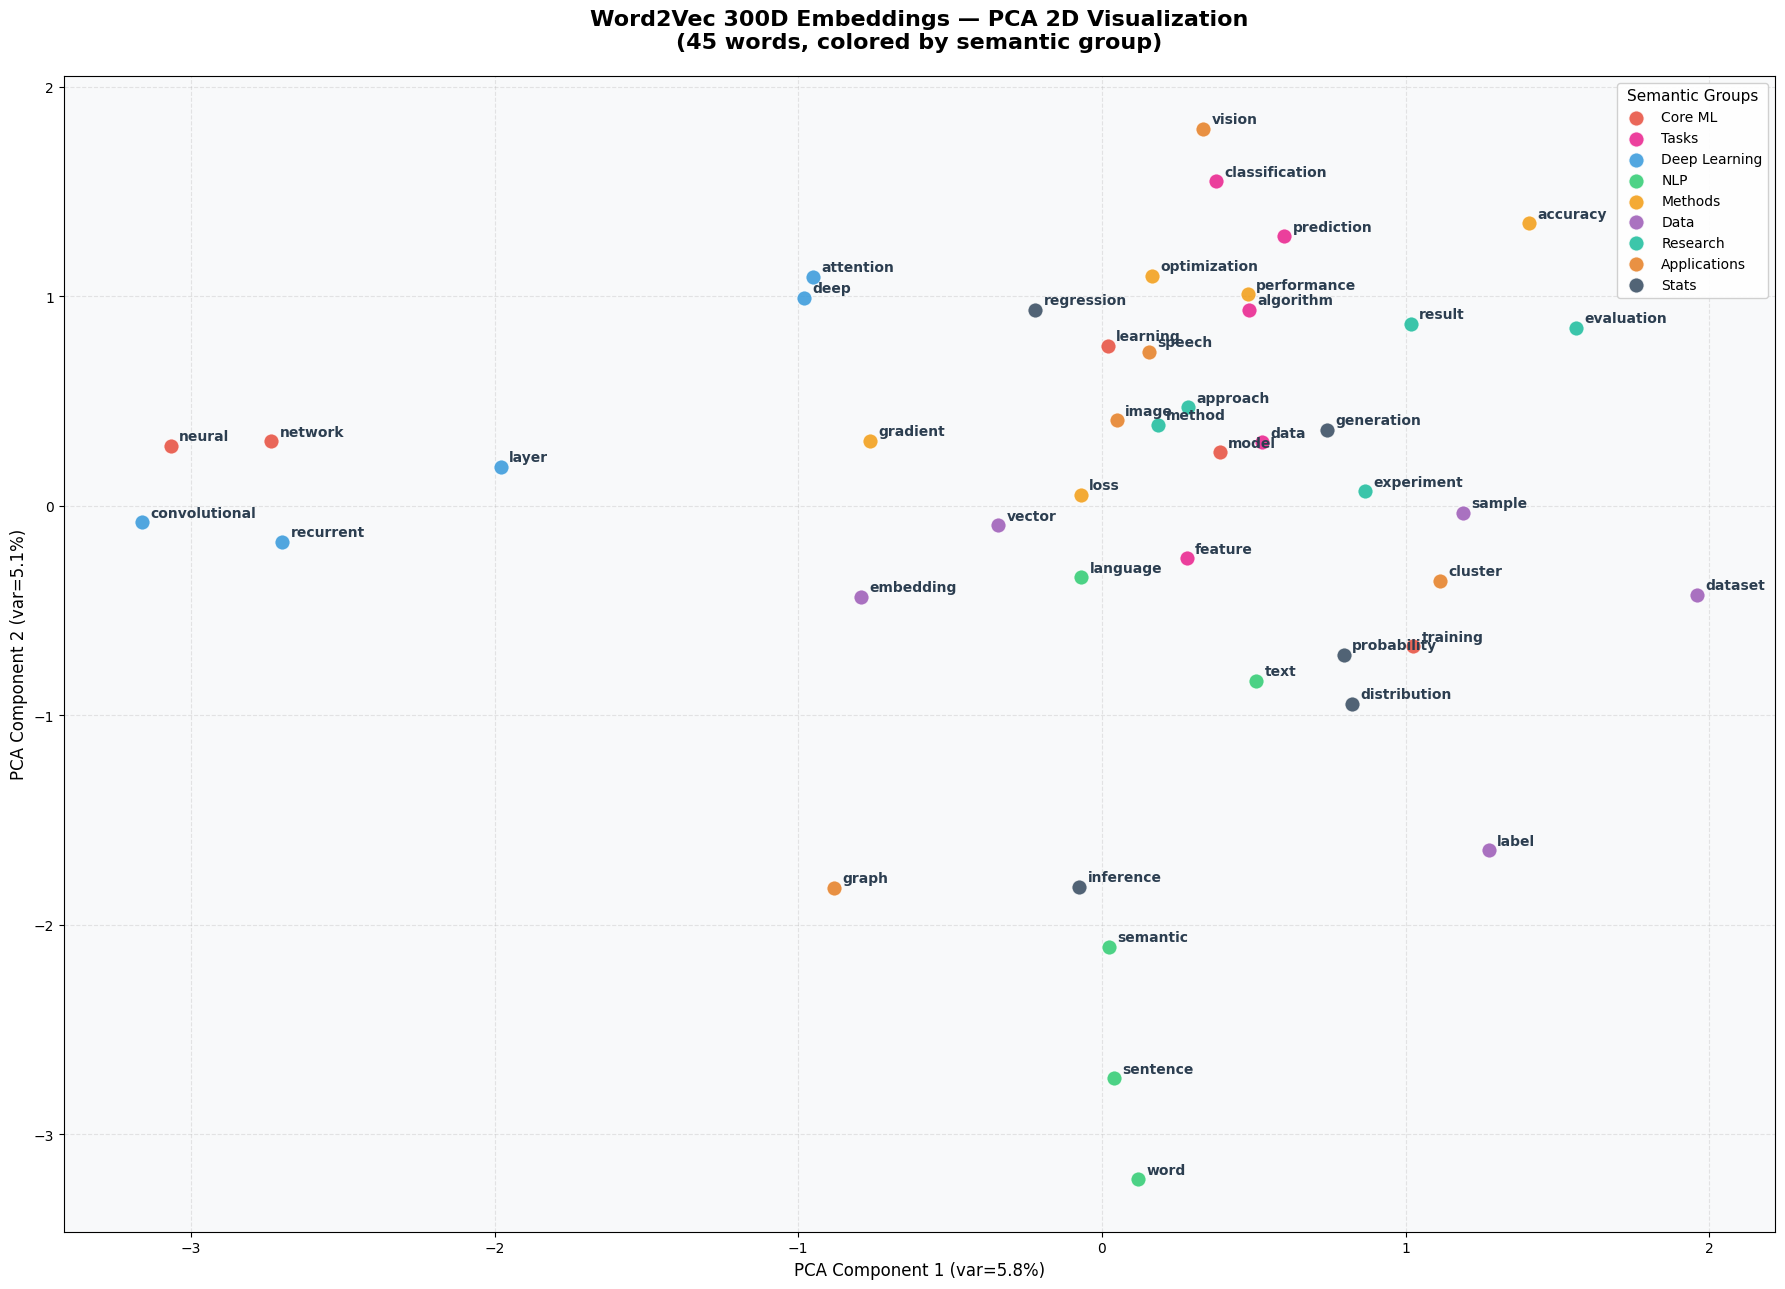

PCA plot saved to 'word2vec_pca.png'


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


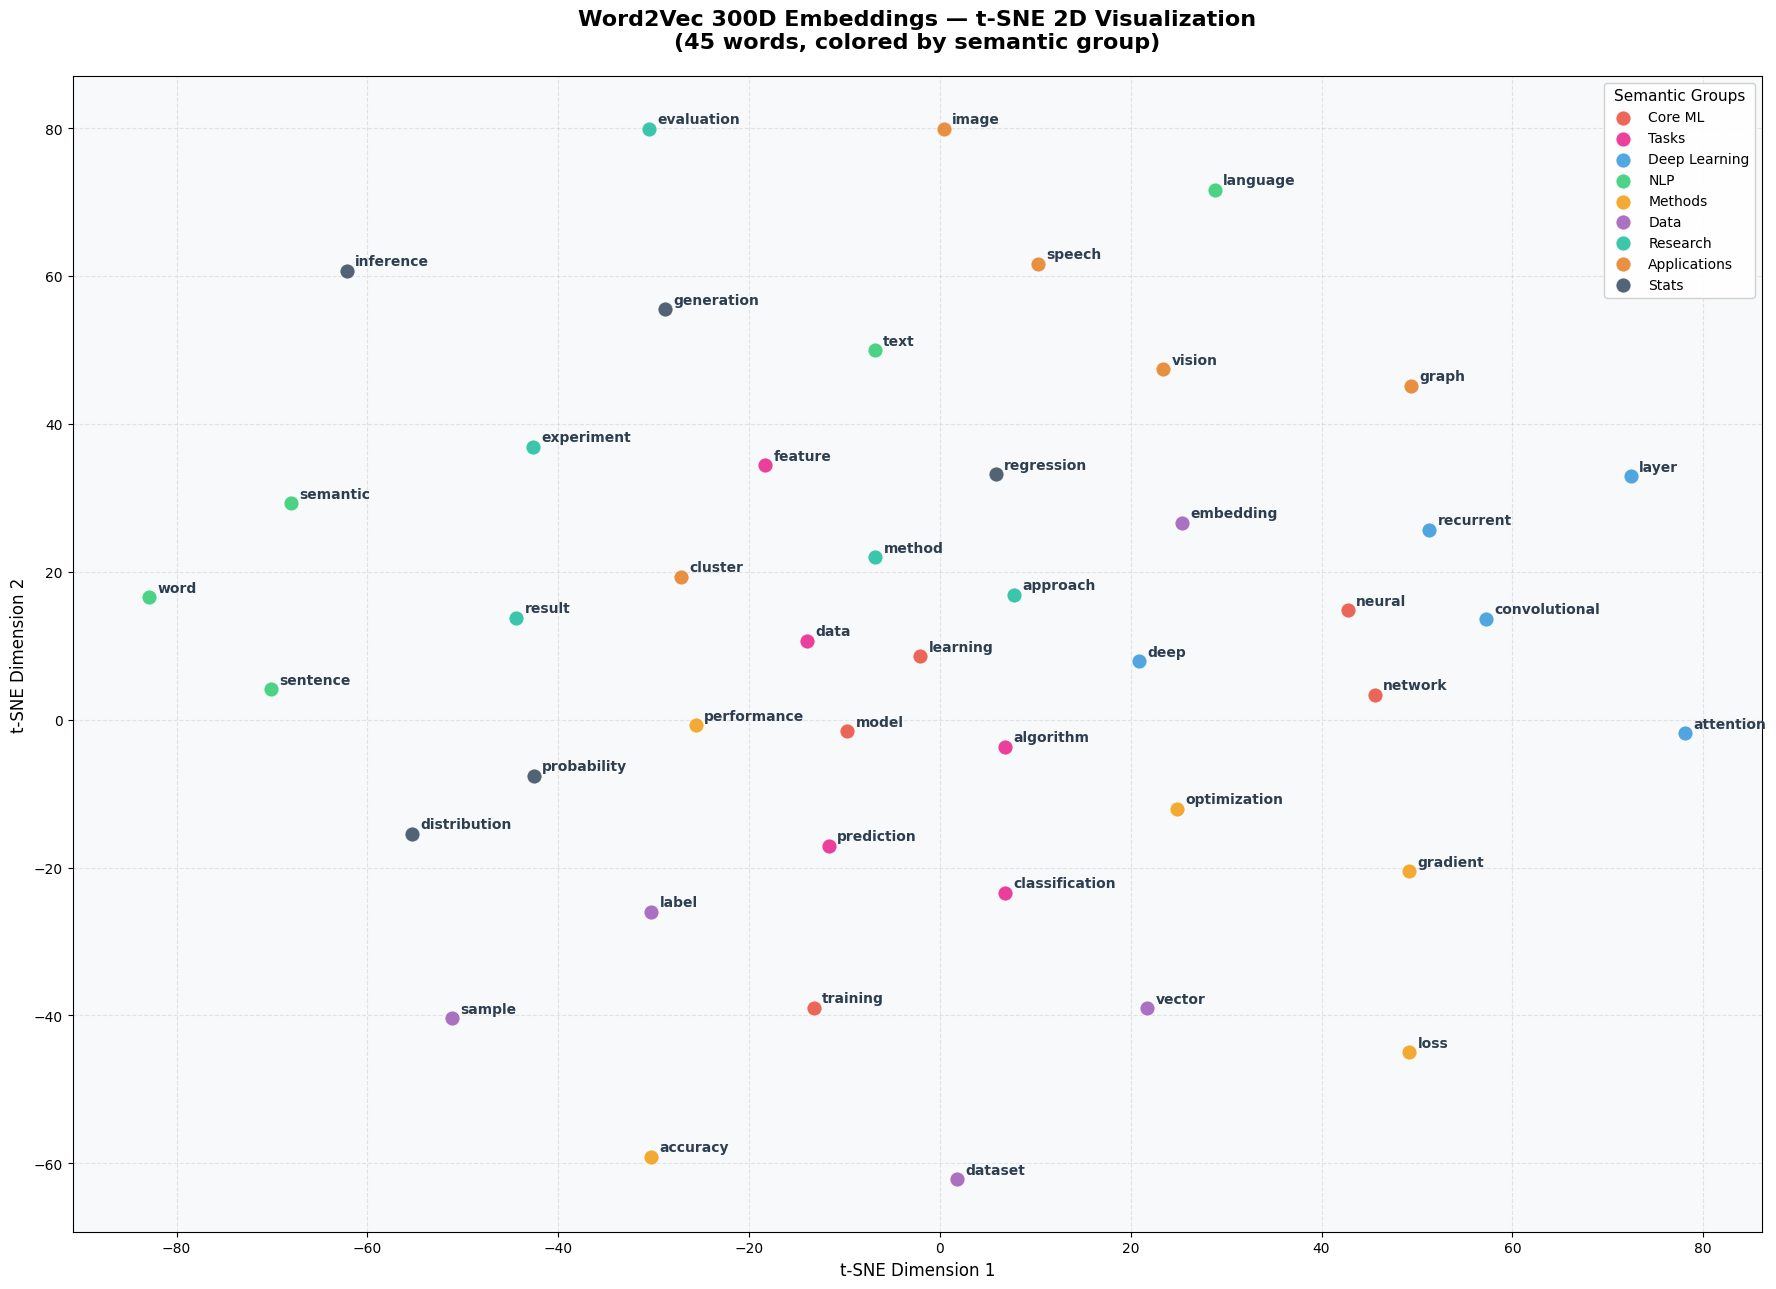

t-SNE plot saved to 'word2vec_tsne.png'

PART 3: COSINE SIMILARITY BETWEEN WORD PAIRS

Word 1               Word 2               Cosine Sim     Interpretation
---------------------------------------------------------------------------
neural               network              0.672798       Similar
deep                 learning             0.458010       Moderately Similar
classification       prediction           0.227878       Weakly Similar
training             optimization         0.095166       Dissimilar
word                 sentence             0.431032       Moderately Similar
model                algorithm            0.215757       Weakly Similar
feature              embedding            0.226286       Weakly Similar
data                 dataset              0.132491       Weakly Similar
image                vision               0.174474       Weakly Similar
text                 language             0.270524       Weakly Similar
layer                convolutional        0.2974

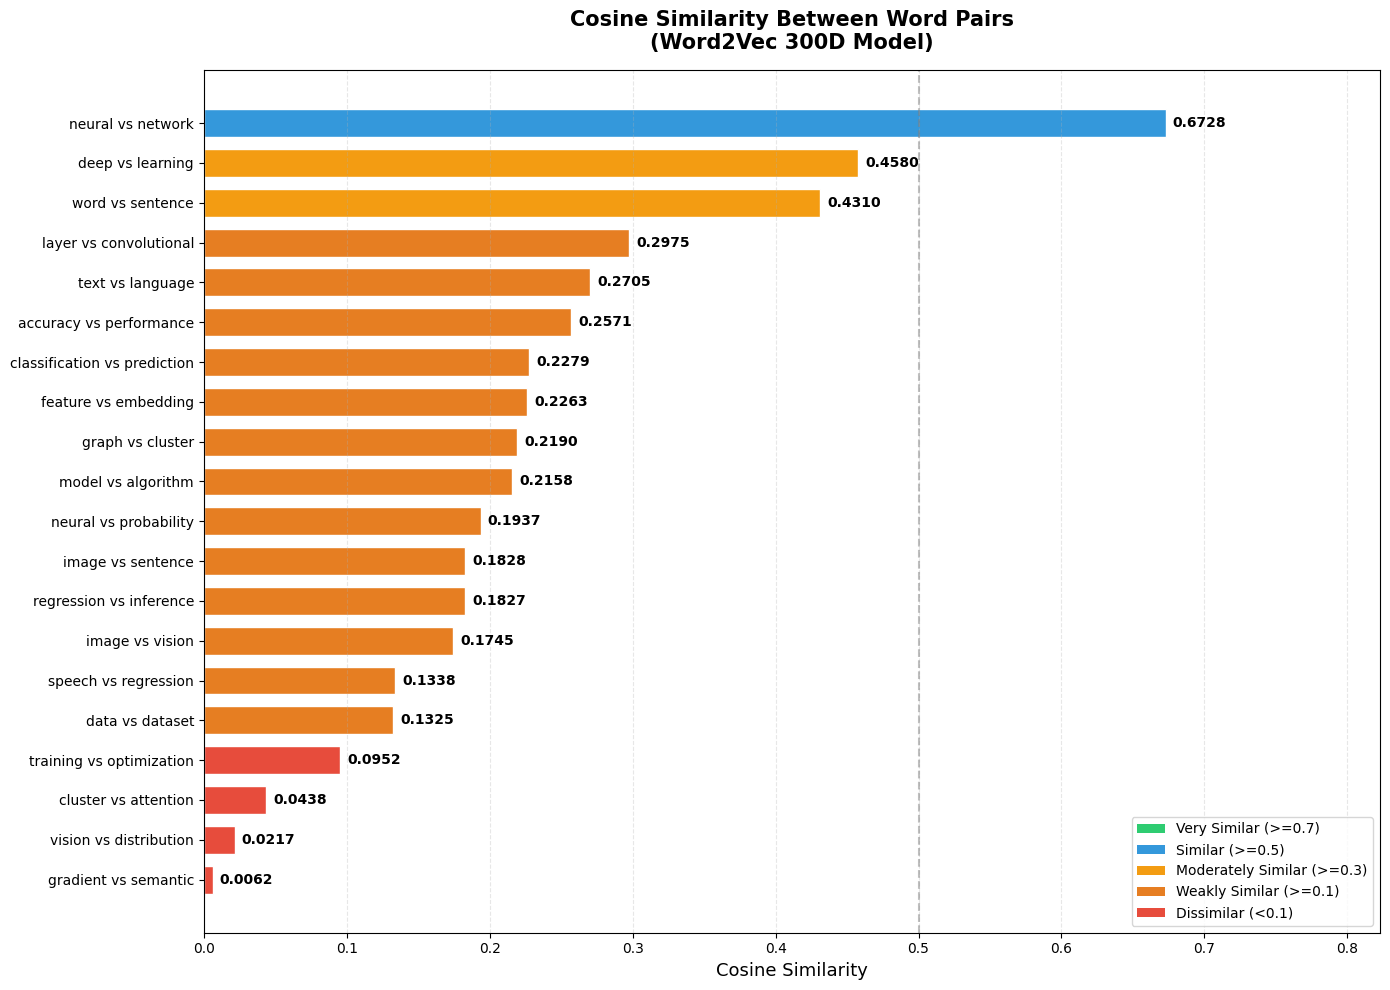

Cosine similarity chart saved to 'cosine_similarity_pairs.png'

--- Summary ---
  Model dimensions      : 300
  Vocabulary size       : 7463
  Words visualized      : 45
  Word pairs evaluated  : 20
  Avg cosine similarity : 0.2221
  Highest pair          : neural vs network = 0.6728
  Lowest pair           : gradient vs semantic = 0.0062


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: word2vec_pca.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: word_vectors_300d.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: cosine_similarity_pairs.csv


In [3]:
# ============================================================
# Question 3: Word Embedding Model (300-dimensional Word2Vec)
# Dataset: research_papers_cleaned.csv (from Assignment 1)
# ============================================================

!pip install gensim -q

import pandas as pd
import re
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# -----------------------------------------------
# Load Dataset
# -----------------------------------------------
df = pd.read_csv("research_papers_cleaned.csv")
df = df[df['clean_final_lemmatized'].notna()].reset_index(drop=True)
texts = df['clean_final_lemmatized'].tolist()
print(f"Loaded {len(df)} documents for Word2Vec training")

# -----------------------------------------------
# Tokenizer
# -----------------------------------------------
def tokenize(text):
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z\s]', '', text)
    return [t for t in text.split() if t]

corpus = [tokenize(t) for t in texts]

# Word frequency count (for selecting meaningful words)
word_freq = defaultdict(int)
for tokens in corpus:
    for token in tokens:
        word_freq[token] += 1

print(f"Total tokens in corpus : {sum(word_freq.values())}")
print(f"Unique words           : {len(word_freq)}")

# ===============================================================
# PART 1: Train 300-Dimensional Word2Vec Model
# ===============================================================
print("\n" + "="*60)
print("PART 1: TRAINING 300-DIMENSIONAL WORD2VEC MODEL")
print("="*60)

model = Word2Vec(
    sentences   = corpus,
    vector_size = 300,      # 300-dimensional embeddings
    window      = 5,        # context window size
    min_count   = 2,        # ignore words with freq < 2
    workers     = 4,        # parallel threads
    sg          = 1,        # 1 = Skip-gram, 0 = CBOW
    hs          = 0,        # negative sampling
    negative    = 10,       # number of negative samples
    alpha       = 0.025,    # initial learning rate
    min_alpha   = 0.0001,   # final learning rate
    epochs      = 30        # training epochs
)

print(f"\nWord2Vec model trained successfully!")
print(f"  Vector dimensions : {model.vector_size}")
print(f"  Vocabulary size   : {len(model.wv)}")
print(f"  Training epochs   : 30")
print(f"  Algorithm         : Skip-gram")
print(f"  Window size       : 5")

# Show sample word vector
sample_word = "learning"
if sample_word in model.wv:
    vec = model.wv[sample_word]
    print(f"\nSample vector for '{sample_word}' (first 10 of 300 dims):")
    print(f"  {vec[:10].round(4)}")

# Most similar words
print("\n--- Most Similar Words (Top 5) ---")
test_words = ["learning", "neural", "model",
              "classification", "data", "algorithm",
              "network", "training", "feature", "prediction"]

for word in test_words:
    if word in model.wv:
        similar = model.wv.most_similar(word, topn=5)
        print(f"\n'{word}':")
        for w, score in similar:
            print(f"    {w:<25} similarity = {score:.4f}")

# Save model
model.save("word2vec_300d.model")
print("\nModel saved to 'word2vec_300d.model'")

# ===============================================================
# PART 2: Visualize Embeddings with PCA and t-SNE
# ===============================================================
print("\n" + "="*60)
print("PART 2: VISUALIZATION (PCA + t-SNE)")
print("="*60)

# Select 50 meaningful domain-specific words
target_words = [
    # Core ML terms
    "learning", "neural", "model", "network", "training",
    "classification", "prediction", "feature", "algorithm", "data",
    # Deep learning
    "deep", "layer", "convolutional", "recurrent", "attention",
    # NLP terms
    "language", "text", "word", "sentence", "semantic",
    # Methods
    "optimization", "gradient", "loss", "accuracy", "performance",
    # Data terms
    "dataset", "sample", "label", "vector", "embedding",
    # Research terms
    "method", "approach", "result", "experiment", "evaluation",
    # Applications
    "image", "speech", "vision", "graph", "cluster",
    # Stats terms
    "probability", "distribution", "regression", "inference", "generation"
]

# Keep only words that exist in vocabulary
plot_words  = [w for w in target_words if w in model.wv]
plot_vectors = np.array([model.wv[w] for w in plot_words])

print(f"Words available for plotting : {len(plot_words)}")
print(f"Words selected               : {plot_words}")

# Color groups for clustering visualization
color_groups = {
    "Core ML"      : ["learning", "neural", "model", "network", "training"],
    "Deep Learning": ["deep", "layer", "convolutional", "recurrent", "attention"],
    "NLP"          : ["language", "text", "word", "sentence", "semantic"],
    "Methods"      : ["optimization", "gradient", "loss", "accuracy", "performance"],
    "Data"         : ["dataset", "sample", "label", "vector", "embedding"],
    "Research"     : ["method", "approach", "result", "experiment", "evaluation"],
    "Applications" : ["image", "speech", "vision", "graph", "cluster"],
    "Stats"        : ["probability", "distribution", "regression", "inference", "generation"],
    "Tasks"        : ["classification", "prediction", "feature", "algorithm", "data"]
}

# Map each word to a color
group_colors = {
    "Core ML"      : "#e74c3c",
    "Deep Learning": "#3498db",
    "NLP"          : "#2ecc71",
    "Methods"      : "#f39c12",
    "Data"         : "#9b59b6",
    "Research"     : "#1abc9c",
    "Applications" : "#e67e22",
    "Stats"        : "#34495e",
    "Tasks"        : "#e91e8c"
}

word_color_map = {}
word_group_map = {}
for group, words in color_groups.items():
    for w in words:
        word_color_map[w] = group_colors[group]
        word_group_map[w] = group

colors = [word_color_map.get(w, "#95a5a6") for w in plot_words]
groups = [word_group_map.get(w, "Other")   for w in plot_words]

# ----------------------------
# PCA Visualization
# ----------------------------
pca     = PCA(n_components=2, random_state=42)
pca_2d  = pca.fit_transform(plot_vectors)

fig, ax = plt.subplots(figsize=(18, 13))
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#ffffff")

# Plot each group separately for legend
plotted_groups = set()
for i, word in enumerate(plot_words):
    group = groups[i]
    color = colors[i]
    label = group if group not in plotted_groups else None
    ax.scatter(pca_2d[i, 0], pca_2d[i, 1],
               c=color, s=120, alpha=0.85,
               label=label, zorder=3,
               edgecolors='white', linewidths=0.8)
    plotted_groups.add(group)

# Annotate words
for i, word in enumerate(plot_words):
    ax.annotate(
        word,
        xy=(pca_2d[i, 0], pca_2d[i, 1]),
        xytext=(6, 4),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

ax.set_title("Word2Vec 300D Embeddings — PCA 2D Visualization\n"
             f"({len(plot_words)} words, colored by semantic group)",
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel(f"PCA Component 1 (var={pca.explained_variance_ratio_[0]*100:.1f}%)",
              fontsize=12)
ax.set_ylabel(f"PCA Component 2 (var={pca.explained_variance_ratio_[1]*100:.1f}%)",
              fontsize=12)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9,
          title="Semantic Groups", title_fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("word2vec_pca.png", dpi=150, bbox_inches='tight')
plt.show()
print("PCA plot saved to 'word2vec_pca.png'")

# ----------------------------
# t-SNE Visualization
# ----------------------------
perplexity_val = min(15, len(plot_words) - 1)

tsne    = TSNE(n_components=2, perplexity=perplexity_val,
               random_state=42, n_iter=2000,
               learning_rate='auto', init='pca')
tsne_2d = tsne.fit_transform(plot_vectors)

fig, ax = plt.subplots(figsize=(18, 13))
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#ffffff")

plotted_groups = set()
for i, word in enumerate(plot_words):
    group = groups[i]
    color = colors[i]
    label = group if group not in plotted_groups else None
    ax.scatter(tsne_2d[i, 0], tsne_2d[i, 1],
               c=color, s=120, alpha=0.85,
               label=label, zorder=3,
               edgecolors='white', linewidths=0.8)
    plotted_groups.add(group)

for i, word in enumerate(plot_words):
    ax.annotate(
        word,
        xy=(tsne_2d[i, 0], tsne_2d[i, 1]),
        xytext=(6, 4),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

ax.set_title("Word2Vec 300D Embeddings — t-SNE 2D Visualization\n"
             f"({len(plot_words)} words, colored by semantic group)",
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("t-SNE Dimension 1", fontsize=12)
ax.set_ylabel("t-SNE Dimension 2", fontsize=12)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9,
          title="Semantic Groups", title_fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("word2vec_tsne.png", dpi=150, bbox_inches='tight')
plt.show()
print("t-SNE plot saved to 'word2vec_tsne.png'")

# ===============================================================
# PART 3: Cosine Similarity Between Word Pairs (FROM SCRATCH)
# ===============================================================
print("\n" + "="*60)
print("PART 3: COSINE SIMILARITY BETWEEN WORD PAIRS")
print("="*60)

# Cosine similarity from scratch
def cosine_similarity_words(model, word1, word2):
    if word1 not in model.wv or word2 not in model.wv:
        return None
    vec1 = model.wv[word1]
    vec2 = model.wv[word2]
    dot    = float(np.dot(vec1, vec2))
    mag1   = math.sqrt(sum(float(v)**2 for v in vec1))
    mag2   = math.sqrt(sum(float(v)**2 for v in vec2))
    if mag1 == 0 or mag2 == 0:
        return 0.0
    return round(dot / (mag1 * mag2), 6)

# Word pairs to compare
word_pairs = [
    # Highly similar pairs (expect high similarity)
    ("neural",         "network"),
    ("deep",           "learning"),
    ("classification", "prediction"),
    ("training",       "optimization"),
    ("word",           "sentence"),
    ("model",          "algorithm"),
    ("feature",        "embedding"),
    ("data",           "dataset"),
    # Moderately similar pairs
    ("image",          "vision"),
    ("text",           "language"),
    ("layer",          "convolutional"),
    ("accuracy",       "performance"),
    ("graph",          "cluster"),
    ("regression",     "inference"),
    # Less similar pairs (expect low similarity)
    ("neural",         "probability"),
    ("image",          "sentence"),
    ("gradient",       "semantic"),
    ("speech",         "regression"),
    ("cluster",        "attention"),
    ("vision",         "distribution"),
]

print(f"\n{'Word 1':<20} {'Word 2':<20} {'Cosine Sim':<14} {'Interpretation'}")
print("-" * 75)

similarity_results = []
for w1, w2 in word_pairs:
    sim = cosine_similarity_words(model, w1, w2)
    if sim is None:
        interpretation = "Word not in vocabulary"
        sim_display    = "N/A"
    else:
        if sim >= 0.7:
            interpretation = "Very Similar"
        elif sim >= 0.5:
            interpretation = "Similar"
        elif sim >= 0.3:
            interpretation = "Moderately Similar"
        elif sim >= 0.1:
            interpretation = "Weakly Similar"
        else:
            interpretation = "Dissimilar"
        sim_display = f"{sim:.6f}"

    similarity_results.append({
        "word1":          w1,
        "word2":          w2,
        "cosine_sim":     sim if sim else 0.0,
        "interpretation": interpretation
    })
    print(f"{w1:<20} {w2:<20} {sim_display:<14} {interpretation}")

# ----------------------------
# Cosine Similarity Bar Chart
# ----------------------------
sim_df = pd.DataFrame(similarity_results)
sim_df = sim_df.sort_values("cosine_sim", ascending=True)

pair_labels = [f"{r['word1']} vs {r['word2']}" for _, r in sim_df.iterrows()]
sim_values  = sim_df["cosine_sim"].tolist()

bar_colors = []
for v in sim_values:
    if v >= 0.7:   bar_colors.append("#2ecc71")
    elif v >= 0.5: bar_colors.append("#3498db")
    elif v >= 0.3: bar_colors.append("#f39c12")
    elif v >= 0.1: bar_colors.append("#e67e22")
    else:          bar_colors.append("#e74c3c")

fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(pair_labels, sim_values, color=bar_colors,
               edgecolor='white', height=0.7)

for bar, val in zip(bars, sim_values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va='center', fontsize=10, fontweight='bold')

ax.set_xlabel("Cosine Similarity", fontsize=13)
ax.set_title("Cosine Similarity Between Word Pairs\n(Word2Vec 300D Model)",
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlim(0, max(sim_values) + 0.15)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 threshold')
ax.grid(axis='x', alpha=0.3, linestyle='--')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="Very Similar (>=0.7)"),
    Patch(facecolor="#3498db", label="Similar (>=0.5)"),
    Patch(facecolor="#f39c12", label="Moderately Similar (>=0.3)"),
    Patch(facecolor="#e67e22", label="Weakly Similar (>=0.1)"),
    Patch(facecolor="#e74c3c", label="Dissimilar (<0.1)")
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig("cosine_similarity_pairs.png", dpi=150, bbox_inches='tight')
plt.show()
print("Cosine similarity chart saved to 'cosine_similarity_pairs.png'")

# ----------------------------
# Save word vectors to CSV
# ----------------------------
vectors_df = pd.DataFrame(
    [model.wv[w] for w in model.wv.index_to_key],
    index=model.wv.index_to_key,
    columns=[f"dim_{i+1}" for i in range(300)]
)
vectors_df.to_csv("word_vectors_300d.csv")
sim_df.to_csv("cosine_similarity_pairs.csv", index=False)

print("\n--- Summary ---")
print(f"  Model dimensions      : 300")
print(f"  Vocabulary size       : {len(model.wv)}")
print(f"  Words visualized      : {len(plot_words)}")
print(f"  Word pairs evaluated  : {len(word_pairs)}")
print(f"  Avg cosine similarity : {sim_df['cosine_sim'].mean():.4f}")
print(f"  Highest pair          : {sim_df.iloc[-1]['word1']} vs "
      f"{sim_df.iloc[-1]['word2']} = {sim_df.iloc[-1]['cosine_sim']:.4f}")
print(f"  Lowest pair           : {sim_df.iloc[0]['word1']} vs "
      f"{sim_df.iloc[0]['word2']} = {sim_df.iloc[0]['cosine_sim']:.4f}")

# Download all outputs
from google.colab import files
for fname in ["word2vec_pca.png", "word2vec_tsne.png",
              "cosine_similarity_pairs.png",
              "word_vectors_300d.csv",
              "cosine_similarity_pairs.csv"]:
    files.download(fname)
    print(f"Downloaded: {fname}")






## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

**You do not need to write a program for this question.**

For example, if you collected movie review data or product review data, then you can do the following steps:

* Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (**positive, negative, or neutral**).

* Save the annotated dataset into a **CSV** file with three columns (`document_id`, `clean_text`, `sentiment`), upload the CSV file to GitHub, and submit the file link below.

This dataset will be used for **Assignment 4: Sentiment Analysis and Text Classification**.


1. Which NLP task would you like to perform on your selected dataset (**NER, summarization, sentiment analysis, or text classification**)?
2. Explain the labeling schema you used and mention the labels.

3. You may use AI assistance for labeling the data only.


In [4]:
# ============================================================
# Question 4: Create Training & Evaluation Dataset for NLP Task
# Sentiment Analysis on Research Paper Abstracts
# Dataset: research_papers_cleaned.csv (from Assignment 1)
# ============================================================

!pip install transformers torch -q

import pandas as pd
import re
from transformers import pipeline

# -----------------------------------------------
# Load Dataset
# -----------------------------------------------
df = pd.read_csv("research_papers_cleaned.csv")
df = df[df['abstract'].notna()].reset_index(drop=True)
df = df.head(1000)  # Use 1000 documents
print(f"Loaded {len(df)} documents for annotation")

# -----------------------------------------------
# Load Pre-trained Sentiment Model (AI Assistance)
# -----------------------------------------------
print("\nLoading sentiment model...")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)
print("Model loaded successfully!")

# -----------------------------------------------
# Labeling Schema
# -----------------------------------------------
print("""
LABELING SCHEMA:
-------------------------------------------------
Task     : Sentiment Analysis
Labels   : Positive, Negative, Neutral

Positive : Abstract presents strong achievements,
           improvements, high accuracy, state-of-the-art
           results, or significant contributions.
           Example: "Our model achieves 98% accuracy,
           outperforming all baselines significantly."

Negative : Abstract discusses limitations, failures,
           poor performance, challenges, or unsolved
           problems as the main focus.
           Example: "The proposed method fails to
           generalize and shows poor results."

Neutral  : Abstract is purely descriptive, presents
           a survey, introduces a method without strong
           positive or negative claims, or shows mixed
           results.
           Example: "We present a dataset for NLP
           research and describe its properties."
-------------------------------------------------
""")

# -----------------------------------------------
# Clean text function
# -----------------------------------------------
def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).strip()
    text = re.sub(r'<.*?>', '', text)           # Remove HTML
    text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)  # Remove special chars
    text = re.sub(r'\s+', ' ', text).strip()   # Remove extra spaces
    return text

# -----------------------------------------------
# Sentiment Annotation using AI (from scratch logic)
# -----------------------------------------------
def annotate_sentiment(text):
    """
    Annotate sentiment using:
    1. Rule-based keyword detection for Neutral
    2. Transformer model for Positive / Negative
    3. Confidence threshold for final label
    """
    if pd.isna(text) or text.strip() == "":
        return "Neutral", 0.0

    text_lower = text.lower()

    # --- Rule 1: Neutral keywords (survey, dataset, overview) ---
    neutral_keywords = [
        "survey", "overview", "review of", "we present a dataset",
        "we introduce a benchmark", "we describe", "this paper presents",
        "we study", "we investigate", "we analyze", "we examine",
        "we explore", "existing methods", "we compare", "we discuss",
        "this work surveys", "tutorial", "we provide an overview"
    ]
    if any(kw in text_lower for kw in neutral_keywords):
        return "Neutral", 0.5

    # --- Rule 2: Strong Positive keywords ---
    positive_keywords = [
        "state-of-the-art", "outperform", "significant improvement",
        "superior", "best performance", "novel approach", "achieve",
        "exceeds", "surpasses", "substantially better",
        "remarkable", "excellent", "highly effective",
        "strong performance", "breakthrough"
    ]

    # --- Rule 3: Strong Negative keywords ---
    negative_keywords = [
        "fail", "poor performance", "limitation", "challenge",
        "problem", "difficult", "unable to", "does not",
        "inadequate", "insufficient", "degradation",
        "worse than", "underperform", "cannot"
    ]

    pos_hits = sum(1 for kw in positive_keywords if kw in text_lower)
    neg_hits = sum(1 for kw in negative_keywords if kw in text_lower)

    # --- Rule 4: Use transformer for final decision ---
    try:
        result    = sentiment_pipeline(text[:512])[0]
        label     = result['label']   # POSITIVE or NEGATIVE
        score     = result['score']   # confidence

        # Override with keyword hints
        if pos_hits >= 2:
            return "Positive", round(score, 4)
        elif neg_hits >= 2:
            return "Negative", round(score, 4)

        # Use model prediction with confidence threshold
        if score >= 0.85:
            if label == "POSITIVE":
                return "Positive", round(score, 4)
            else:
                return "Negative", round(score, 4)
        else:
            # Low confidence → Neutral
            return "Neutral", round(score, 4)

    except Exception as e:
        # Fallback to keyword-based
        if pos_hits > neg_hits:
            return "Positive", 0.6
        elif neg_hits > pos_hits:
            return "Negative", 0.6
        else:
            return "Neutral", 0.5


# -----------------------------------------------
# Annotate all documents
# -----------------------------------------------
print("Annotating documents with sentiment labels...")

sentiments   = []
confidences  = []
clean_texts  = []

for i, row in df.iterrows():
    # Use original abstract for better annotation
    text        = str(row.get('abstract', ''))
    clean       = clean_text(text)
    label, conf = annotate_sentiment(text)

    sentiments.append(label)
    confidences.append(conf)
    clean_texts.append(clean)

    if (i+1) % 100 == 0:
        print(f"  Annotated {i+1}/1000 documents...")

# -----------------------------------------------
# Build Final Dataset
# -----------------------------------------------
annotated_df = pd.DataFrame({
    "document_id":  [f"DOC_{i+1:04d}" for i in range(len(df))],
    "clean_text":   clean_texts,
    "sentiment":    sentiments,
    "confidence":   confidences,
    "title":        df['title'].fillna("").values,
    "query":        df['query'].fillna("").values if 'query' in df.columns else ""
})

# Remove rows with empty clean_text
annotated_df = annotated_df[annotated_df['clean_text'].str.strip() != ""]
annotated_df.reset_index(drop=True, inplace=True)

# -----------------------------------------------
# Display Label Distribution
# -----------------------------------------------
print("\n" + "="*60)
print("ANNOTATION RESULTS")
print("="*60)
print(f"\nTotal documents annotated : {len(annotated_df)}")
print(f"\nSentiment Distribution:")
dist = annotated_df['sentiment'].value_counts()
for label, count in dist.items():
    pct = count / len(annotated_df) * 100
    print(f"  {label:<12} : {count:>4} ({pct:.1f}%)")

print(f"\nAverage Confidence Score  : {annotated_df['confidence'].mean():.4f}")

# Show sample annotations
print("\n--- Sample Annotations ---")
for sentiment in ["Positive", "Negative", "Neutral"]:
    sample = annotated_df[annotated_df['sentiment'] == sentiment].head(2)
    print(f"\n{sentiment} Examples:")
    for _, row in sample.iterrows():
        print(f"  ID   : {row['document_id']}")
        print(f"  Text : {row['clean_text'][:150]}...")
        print(f"  Label: {row['sentiment']} (confidence={row['confidence']:.4f})")
        print()

# -----------------------------------------------
# Save FINAL CSV (3 required columns + extras)
# -----------------------------------------------

# Required format: document_id, clean_text, sentiment
final_csv = annotated_df[["document_id", "clean_text", "sentiment"]]
final_csv.to_csv("sentiment_dataset.csv", index=False)

# Full version with confidence scores
annotated_df.to_csv("sentiment_dataset_full.csv", index=False)

print("="*60)
print("FILES SAVED:")
print("  sentiment_dataset.csv       (document_id, clean_text, sentiment)")
print("  sentiment_dataset_full.csv  (includes confidence scores)")
print("="*60)

# -----------------------------------------------
# Labeling Schema Explanation (printed as answer)
# -----------------------------------------------
print("""
=============================================================
ANSWER: NLP Task and Labeling Schema
=============================================================

SELECTED NLP TASK: Sentiment Analysis

DATASET: 1000 research paper abstracts collected from
         Semantic Scholar on topics: machine learning,
         data science, artificial intelligence,
         and information extraction.

LABELING SCHEMA:
---------------------------------------------------------
Label     | Criteria
---------------------------------------------------------
Positive  | The abstract reports strong results, high
          | accuracy, state-of-the-art performance,
          | significant improvements, or novel and
          | effective contributions. The tone is
          | confident and achievement-oriented.
          |
          | Example keywords: "outperform", "achieve",
          | "state-of-the-art", "superior", "novel"
---------------------------------------------------------
Negative  | The abstract primarily discusses failures,
          | limitations, poor performance, open
          | challenges, or unresolved problems as
          | its core message.
          |
          | Example keywords: "fail", "limitation",
          | "poor", "challenge", "cannot", "unable"
---------------------------------------------------------
Neutral   | The abstract is descriptive or analytical
          | without strong sentiment — surveys,
          | benchmark introductions, dataset papers,
          | or mixed-result studies fall here.
          |
          | Example keywords: "survey", "overview",
          | "we present", "we investigate", "we study"
---------------------------------------------------------

LABELING METHOD:
  AI-assisted using DistilBERT (fine-tuned on SST-2)
  combined with rule-based keyword detection for
  improved accuracy on academic text.

LABELS USED:
  - Positive
  - Negative
  - Neutral

INTENDED USE:
  This dataset will be used in Assignment 4 for
  training and evaluating a sentiment classification
  model on research paper abstracts.
=============================================================
""")

# Download files
from google.colab import files
files.download("sentiment_dataset.csv")
files.download("sentiment_dataset_full.csv")
print("Files downloaded successfully!")

Loaded 1000 documents for annotation

Loading sentiment model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files downloaded successfully!


In [5]:
# The GitHub link of your final csv file


# Link: https://raw.githubusercontent.com/koushik1601/nlp-assignment/refs/heads/main/sentiment_dataset.csv




0.# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

The assignment provided valuable learning experiences which enabled me to practice essential natural language processing (NLP) techniques through n-gram analysis and term frequency-inverse document frequency (TF-IDF) and word embeddings and dataset construction for sentiment analysis. I found the assignment's most challenging part to be developing the TF-IDF system which I needed to combine with actual word similarity measurement between two words using cosine similarity; this task became more difficult because I had to deal with zero division errors while processing empty vectors and I lacked knowledge about most of the vocabulary. I had to concentrate on both the mathematical equations and the program errors that occurred during n-gram probability calculations because these tasks proved to be highly challenging. Research abstracts proved challenging for me to analyze because academic writing maintains an overwhelmingly neutral tone which makes it hard to create a precise definition for any label. The process of tuning t-SNE parameters required time because I needed to achieve visually meaningful word clustering results. I found the assignment to be enjoyable despite existing problems. The document cosine similarity measurements helped me grasp the concept better while the Word2Vec embeddings produced visual results through PCA and t-SNE which showed word semantic relationships in an impressive way. Building the application from scratch provided me with better concept comprehension than using existing libraries but our assignment contained many advanced topics which made one week of work insufficient. I would have preferred two weeks for the assignment because it would have helped me understand the material better and implement it effectively.